In [96]:
import pandas as pd

Loading the Customer Data which is csv file

In [2]:
customers = pd.read_csv("../Data/European_Bank.csv")

Analyazing the data 
1. shape
2. information -> number of columns, type_of_col, null_value_count
3. statical values --> getting min, max, mean, median of each col

In [4]:
customers.shape

(10000, 14)

In [5]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [12]:
customers.describe(include="all")

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


In [14]:
customers.isnull().sum() # there is no null columns

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Analyzing the Exited with other columns that how they are interrelated

In [26]:
customers['Exited'].value_counts(normalize=True) *100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

#### Observation
1. Total Entries : 10000
2. Churn Customers : 20.37% and Not churn 79.63%
3. Year -> this is same for all rows
4. CustomerId -> this value is unique for all rows
5. Surname -> this it nominal change to churn
6. Age range: (18-92)
7. Geography : ['spain', 'France', 'Germany']
8. Gender : ['male', 'female']
9. Tenure : [0-10]
10. No_of_product : [1-4]

Data Cleaning

Here in this problem year = 2025 is same for all
and surname does not impact on the prediction
CustomerId is unique for each entry just remove that as well

In [ ]:
customers = customers.drop(['Year','CustomerId','Surname'],axis=1)

now converting the label value column to number by using the get_dummies method of pandas because there is 

Geography -> ['France','Spain','Germany']

Gender -> ['male','Female']

In [24]:
# creating dumies entry for Geography example for       spain   france  germnay
#                                              row1     1       0           0 and similar for others

customers = pd.get_dummies(customers, columns=['Geography','Gender'],drop_first='first',dtype=int)

In [25]:
customers.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [27]:
customers.groupby('Exited').mean(numeric_only=True)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
Exited,,,,,,,,,,,
0,651.853196,37.408389,5.033279,72745.296779,1.544267,0.707146,0.554565,99738.391772,0.212859,0.259199,0.572523
1,645.351497,44.837997,4.932744,91108.539337,1.475209,0.699067,0.360825,101465.677531,0.399607,0.202749,0.440844


Visualizing the data

In [20]:
import seaborn as sns

<Axes: xlabel='Exited', ylabel='count'>

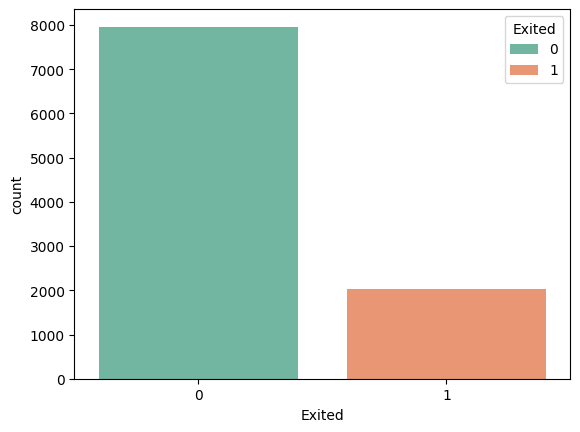

In [28]:
sns.countplot(data=customers, x="Exited", hue="Exited", palette='Set2')

### UNEVEN output so using the sampling to fit the diveration
1. over sampling -> increase the number of under represented (minority) class samples. (used when small dataset)
2. under sampling -> decrease the number of over represented (majority) class sample. (Used when massive dataset)

In [69]:
# spliting the data set into input and output
input = customers.drop( ['Exited'],axis=1)
output = customers['Exited']

In [97]:
from sklearn.model_selection import train_test_split

In [70]:
# spleting the data set to train and test
x_train, x_test , y_train, y_test = train_test_split(input,output,test_size=0.3,random_state=42)

**we can only apply the SMOTE to the train not on the testing because it lead to incorrect output for real data set because it create new entry to minimize the differnt betweent the output column**

In [ ]:
from imblearn.over_sampling import SMOTE

In [72]:
# now using the SMOTE so we can over come the gap between the output 
# 0    7963         # 1    2037
x_train, y_train = SMOTE().fit_resample(x_train,y_train)

In [73]:
x_train.value_counts()

CreditScore  Age  Tenure  Balance        NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  Gender_Male
619          32   4       175406.130000  2              1          1               172792.430000    0                  1                0              1
643          34   7       160426.070000  1              0          1               188533.110000    1                  0                0              1
561          33   6       0.000000       2              0          0               173680.390000    0                  0                1              1
618          41   8       37702.790000   1              1          1               195775.480000    1                  0                1              1
714          37   9       148466.930000  2              0          1               151280.960000    0                  0                1              1
                                                                                       

In [74]:
y_train.value_counts()

Exited
1    5547
0    5547
Name: count, dtype: int64

### using all known model to evaluate a perfect model for our project

In [76]:
# now training the different model on the training data set
from sklearn.linear_model import LogisticRegression
# an ensemble trees: highly reliable and robust
from sklearn.ensemble import RandomForestClassifier
# scikit-learn fast boosting model for 10K + 
from sklearn.ensemble import HistGradientBoostingClassifier
# XGBoost high, performance boosting king
from xgboost import XGBClassifier
# linear support vector classifier 
from sklearn.svm import LinearSVC
# classifier based on what the closests rows look like
from sklearn.neighbors import KNeighborsClassifier
# Gaussian naive bayes : fast probablistic classfier
from sklearn.naive_bayes import GaussianNB

Importing comparision metrics to compare different models

In [80]:
# model comparisions for the different models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

**Creating dictionary for differnt model to check there metrics**

In [77]:
models = {
    'LogisticReg': LogisticRegression(max_iter=1000,random_state=42),
    'RandomFor': RandomForestClassifier(random_state=42),
    'HistGradientBoostingClassifier': HistGradientBoostingClassifier(random_state=42),
    'XGBoost':XGBClassifier(random_state=42, eval_metric="logloss"),
    'LinearSVC': LinearSVC(random_state=42),
    'KNeighborsClass': KNeighborsClassifier(),
    'GaussianNB': GaussianNB()
}

**training each model and test each model and calculate the**

**accuracy, precision, recall and f1 along with roc_auc_score**

In [ ]:
result = {}
for model_name, model in models.items():
    model.fit(x_train,y_train)

    # predicting the value for test data
    y_pred = model.predict(x_test)

    acc_sc = accuracy_score(y_pred,y_test)
    pre_sc = precision_score(y_pred,y_test)
    f1_sc = f1_score(y_pred,y_test)
    roc_acc_sc = roc_auc_score(y_pred,y_test)

    result[model_name] = {
        "Accuray_score" : acc_sc,
        "Presicion_score": pre_sc,
        "f1_score": f1_sc,
        "roc_acc_sc": roc_acc_sc
    }

In [84]:
result_df = pd.DataFrame(result)

**Comparing the different model accuray, precision, f1_score and roc_acc_score**

In [85]:
result_df

,LogisticReg,RandomFor,HistGradientBoostingClassifier,XGBoost,LinearSVC,KNeighborsClass,GaussianNB
Accuray_score,0.734333,0.815667,0.816667,0.818667,0.731667,0.573333,0.671333
Presicion_score,0.570205,0.614726,0.645548,0.614726,0.568493,0.421233,0.683219
f1_score,0.455229,0.564910,0.578221,0.568938,0.452008,0.277652,0.447309
roc_acc_sc,0.630250,0.712643,0.716411,0.716300,0.627996,0.510268,0.614861


In above comparision **HistGridientBoostingClassifier and XGBoostClassifier** perform best chooseing **XGBoostClassifier**

**Saving best model for predictions**

In [87]:
import joblib

In [88]:
# now smote the full data then train with whole that then save the model
input , output = SMOTE(random_state=42).fit_resample(input,output)

In [91]:
input.shape, output.shape

((15926, 11), (15926,))

In [92]:
final_model = XGBClassifier(random_state=42, eval_metric="logloss")

In [93]:
# training the model
final_model.fit(input,output)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [95]:
joblib.dump(final_model,"../Models/churn_prediction.pkl")

['../Models/churn_prediction.pkl']

In [98]:
input.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male'],
      dtype='str')

In [99]:
customers['Gender_Male'][0]

np.int64(0)

In [100]:
customers[customers['Exited'] == 1]

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
5,645,44,8,113755.78,2,1,0,149756.71,1,0,1,1
7,376,29,4,115046.74,4,1,0,119346.88,1,1,0,0
16,653,58,1,132602.88,1,1,0,5097.67,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9981,498,42,3,152039.70,1,1,1,53445.17,1,1,0,1
9982,655,46,7,137145.12,1,1,0,115146.40,1,1,0,0
9991,597,53,4,88381.21,1,1,0,69384.71,1,0,0,0
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
